# Nepali Tokenizer Benchmark

This notebook recreates the tokenizer-efficiency experiment behind the Nepali tokenizer case study.

It measures how many tokens different model tokenizers need for Nepali text compared with English text. The headline metric is:

`Nepali tax = Nepali tokens per word / English tokens per word`

A 3.0x tax means Nepali takes roughly three times as many tokens as English for the same word count. That affects API cost, effective context length, and prompt-side compute.

The notebook can run in two modes:

1. **Full local mode**: uses `data/clean/*.jsonl` and local tokenizer artifacts if present.
2. **Portable smoke mode**: uses a small embedded Nepali/English sample so the notebook is still readable without the private/local corpus files.

Model weights are not downloaded. This is a tokenizer benchmark only. The committed demo compares three local tokenizer artifacts: Phi-4 as a high-tax baseline, Qwen3 as the base model tokenizer, and the Qwen3 tokenizer extended with Nepali pieces.

## Setup

Install these if needed:

```bash
pip install transformers tiktoken datasets sentencepiece pandas matplotlib
```

Some gated tokenizers may require `huggingface-cli login` or an accepted model license. If a tokenizer cannot be loaded, this notebook records the error and continues.

In [7]:
from __future__ import annotations

import json
import math
import html
from pathlib import Path

import pandas as pd

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    def display(value):
        print(value)

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

def find_repo_root(start: Path) -> Path:
    """Find the project root whether the notebook is launched from repo/ or repo/notebooks/."""
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / 'tokenizers' / 'extended' / 'qwen3-nepali').exists():
            return path
    raise FileNotFoundError('Could not find repo root containing tokenizers/extended/qwen3-nepali')

ROOT = find_repo_root(Path.cwd())
DATA_DIR = ROOT / 'data' / 'clean'
TOKENIZER_DIR = ROOT / 'tokenizers'

def show_cards(items):
    cards = ''.join(
        f"""
        <div style='border:1px solid #ddd;border-radius:8px;padding:14px 16px;background:#fafafa'>
          <div style='font-size:12px;text-transform:uppercase;letter-spacing:.04em;color:#666'>{html.escape(label)}</div>
          <div style='font-size:24px;font-weight:700;margin-top:4px'>{html.escape(value)}</div>
        </div>
        """
        for label, value in items
    )
    if HTML is None:
        for label, value in items:
            print(f'{label}: {value}')
    else:
        display(HTML(f"<div style='display:grid;grid-template-columns:repeat(auto-fit,minmax(180px,1fr));gap:12px;margin:12px 0 18px'>{cards}</div>"))

DEVANAGARI_START = 0x0900
DEVANAGARI_END = 0x097F

def is_devanagari_text(text: str) -> bool:
    return any(DEVANAGARI_START <= ord(c) <= DEVANAGARI_END for c in text)

def load_jsonl(path: Path) -> list[dict]:
    with path.open(encoding='utf-8') as f:
        return [json.loads(line) for line in f]

def as_docs(texts: list[str], source: str) -> list[dict]:
    return [{'text': text, 'source': source} for text in texts]


## Load Evaluation Text

The compact before/after benchmark uses the 2,000-document Nepali CC-100 split and the 2,000-document English CC-100 split. Those derived JSONL files are intentionally not committed to git because they are source-derived data.

If the JSONL files exist locally, this notebook uses them. Otherwise it falls back to a small embedded sample for demonstration.

In [8]:
nepali_file = DATA_DIR / 'nepali_cc100.jsonl'
english_file = DATA_DIR / 'english_cc100.jsonl'

if nepali_file.exists() and english_file.exists():
    nepali_docs = load_jsonl(nepali_file)
    english_docs = load_jsonl(english_file)
    data_mode = 'local CC-100 benchmark split'
else:
    nepali_docs = as_docs([
        'नेपालको राजधानी काठमाडौं हो। यो शहर ऐतिहासिक, सांस्कृतिक, र प्रशासनिक दृष्टिले महत्त्वपूर्ण छ।',
        'सगरमाथा संसारको सबैभन्दा अग्लो हिमाल हो। यसको उचाइ ८,८४८.८६ मिटर छ।',
        'नेपाली भाषा देवनागरी लिपिमा लेखिन्छ र नेपालका धेरै क्षेत्रमा प्रयोग गरिन्छ।',
        'नेपालमा कृषि, पर्यटन, र वैदेशिक रोजगारी अर्थतन्त्रका महत्त्वपूर्ण क्षेत्रहरू हुन्।',
    ], 'embedded-nepali-sample')
    english_docs = as_docs([
        'The capital of Nepal is Kathmandu. The city is important historically, culturally, and administratively.',
        'Mount Everest is the tallest mountain in the world. Its height is 8,848.86 meters.',
        'The Nepali language is written in the Devanagari script and is used across many regions of Nepal.',
        'Agriculture, tourism, and foreign employment are important sectors of Nepal\'s economy.',
    ], 'embedded-english-sample')
    data_mode = 'embedded smoke sample'

ne_words = sum(len(doc['text'].split()) for doc in nepali_docs)
en_words = sum(len(doc['text'].split()) for doc in english_docs)

print(f'Data mode: {data_mode}')
print(f'Nepali docs: {len(nepali_docs):,}, words: {ne_words:,}')
print(f'English docs: {len(english_docs):,}, words: {en_words:,}')

show_cards([
    ('data mode', data_mode),
    ('Nepali docs', f'{len(nepali_docs):,}'),
    ('Nepali words', f'{ne_words:,}'),
    ('English words', f'{en_words:,}'),
])


Data mode: local CC-100 benchmark split
Nepali docs: 2,000, words: 444,560
English docs: 2,000, words: 107,234


## Tokenizer Registry

The public notebook intentionally uses only local tokenizer files committed with this repo. That keeps the demo stable after clone: no Hugging Face login, no gated tokenizer access, and no model-weight downloads.

- `Phi-4`: a high-tax baseline from the original benchmark.
- `Qwen3 base`: the base tokenizer for the model experiment.
- `Qwen3 Nepali extended`: the same Qwen3 tokenizer with selected Nepali tokens added.

The full multi-tokenizer benchmark is kept in the scripts/results. This notebook is the small reproducible artifact for readers.

In [9]:
tokenizer_specs = [
    {'name': 'Phi-4 baseline', 'kind': 'hf_local', 'path': TOKENIZER_DIR / 'phi4'},
    {'name': 'Qwen3 base', 'kind': 'hf_local', 'path': TOKENIZER_DIR / 'qwen3'},
    {'name': 'Qwen3 Nepali extended', 'kind': 'hf_local', 'path': TOKENIZER_DIR / 'extended' / 'qwen3-nepali'},
]

print('Tokenizers to try:')
for spec in tokenizer_specs:
    print('-', spec['name'])


Tokenizers to try:
- Phi-4 baseline
- Qwen3 base
- Qwen3 Nepali extended


## Load Tokenizers

This section only loads local tokenizer files, not model weights. If one of the expected tokenizer directories is missing, the notebook shows the missing path clearly.

In [10]:
def load_encode_fn(spec: dict):
    if spec['kind'] != 'hf_local':
        raise ValueError(f"unsupported tokenizer kind: {spec['kind']}")

    path = spec['path']
    if not path.exists():
        raise FileNotFoundError(path)

    from transformers import AutoTokenizer
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
    tok = AutoTokenizer.from_pretrained(str(path), trust_remote_code=True)
    return lambda text: tok.encode(text, add_special_tokens=False), len(tok), tok.__class__.__name__

loaded = []
errors = []

for spec in tokenizer_specs:
    try:
        encode_fn, vocab_size, tokenizer_type = load_encode_fn(spec)
        loaded.append({**spec, 'encode_fn': encode_fn, 'vocab_size': vocab_size, 'tokenizer_type': tokenizer_type})
        print(f"loaded: {spec['name']} ({tokenizer_type}, vocab={vocab_size:,})")
    except Exception as exc:
        errors.append({'name': spec['name'], 'error': repr(exc)})
        print(f"skipped: {spec['name']} -> {exc}")

print(f'Loaded {len(loaded)} tokenizers; skipped {len(errors)}')
if len(loaded) != len(tokenizer_specs):
    raise RuntimeError('One or more committed tokenizer artifacts are missing. See errors above.')
if errors:
    pd.DataFrame(errors)


/Users/calld-admin/portfolio/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded: Phi-4 baseline (GPT2Tokenizer, vocab=100,352)
loaded: Qwen3 base (Qwen2Tokenizer, vocab=151,669)
loaded: Qwen3 Nepali extended (Qwen2Tokenizer, vocab=166,925)
Loaded 3 tokenizers; skipped 0


## Benchmark

For each tokenizer, we count total tokens and divide by whitespace word count. This is not a perfect linguistic segmentation metric, but it maps directly to practical LLM costs and context-window usage.

In [11]:
def count_tokens(encode_fn, docs):
    total_tokens = 0
    failed_docs = 0
    for doc in docs:
        try:
            ids = encode_fn(doc['text'])
        except Exception:
            failed_docs += 1
            continue
        if not ids:
            failed_docs += 1
            continue
        total_tokens += len(ids)
    return total_tokens, failed_docs

rows = []
for item in loaded:
    ne_tokens, ne_failed = count_tokens(item['encode_fn'], nepali_docs)
    en_tokens, en_failed = count_tokens(item['encode_fn'], english_docs)
    ne_tpw = ne_tokens / ne_words if ne_words else math.nan
    en_tpw = en_tokens / en_words if en_words else math.nan
    tax = ne_tpw / en_tpw if en_tpw else math.nan
    rows.append({
        'tokenizer': item['name'],
        'type': item['tokenizer_type'],
        'vocab_size': item['vocab_size'],
        'ne_tokens': ne_tokens,
        'en_tokens': en_tokens,
        'ne_tokens_per_word': ne_tpw,
        'en_tokens_per_word': en_tpw,
        'nepali_tax': tax,
        'failed_ne_docs': ne_failed,
        'failed_en_docs': en_failed,
    })

df = pd.DataFrame(rows).sort_values('nepali_tax')
qwen_base_tokens = df.loc[df['tokenizer'].eq('Qwen3 base'), 'ne_tokens'].iloc[0]
df['token_reduction_vs_qwen3'] = 1 - (df['ne_tokens'] / qwen_base_tokens)

show_cards([
    ('best tokenizer', df.iloc[0]['tokenizer']),
    ('best Nepali tax', f"{df.iloc[0]['nepali_tax']:.2f}x"),
    ('Qwen3 extended reduction', f"{df.loc[df['tokenizer'].eq('Qwen3 Nepali extended'), 'token_reduction_vs_qwen3'].iloc[0]:.1%}"),
    ('failed docs', f"{int(df['failed_ne_docs'].sum())}"),
])

display_cols = {
    'tokenizer': 'Tokenizer',
    'type': 'Implementation',
    'vocab_size': 'Vocab size',
    'ne_tokens': 'Nepali tokens',
    'ne_tokens_per_word': 'NE tok/word',
    'en_tokens_per_word': 'EN tok/word',
    'nepali_tax': 'Nepali tax',
    'token_reduction_vs_qwen3': 'Reduction vs Qwen3',
}
pretty = df[list(display_cols)].rename(columns=display_cols)

def highlight_project(row):
    if row['Tokenizer'] == 'Qwen3 Nepali extended':
        return ['background-color:#edf7ed;font-weight:600'] * len(row)
    if row['Tokenizer'] == 'Qwen3 base':
        return ['background-color:#f7f7f7'] * len(row)
    return [''] * len(row)

display(pretty.style
    .apply(highlight_project, axis=1)
    .format({
        'Vocab size': '{:,.0f}',
        'Nepali tokens': '{:,.0f}',
        'NE tok/word': '{:.2f}',
        'EN tok/word': '{:.2f}',
        'Nepali tax': '{:.2f}x',
        'Reduction vs Qwen3': '{:.1%}',
    })
    .hide(axis='index')
)


Tokenizer,Implementation,Vocab size,Nepali tokens,NE tok/word,EN tok/word,Nepali tax,Reduction vs Qwen3
Qwen3 Nepali extended,Qwen2Tokenizer,"166,925","1,415,539",3.18,1.25,2.55x,48.1%
Qwen3 base,Qwen2Tokenizer,"151,669","2,724,999",6.13,1.25,4.90x,0.0%
Phi-4 baseline,GPT2Tokenizer,"100,352","3,155,696",7.10,1.25,5.68x,-15.8%


## Chart

Lower is better. If local artifacts are available, the chart includes the project tokenizers so the before/after effect is visible.

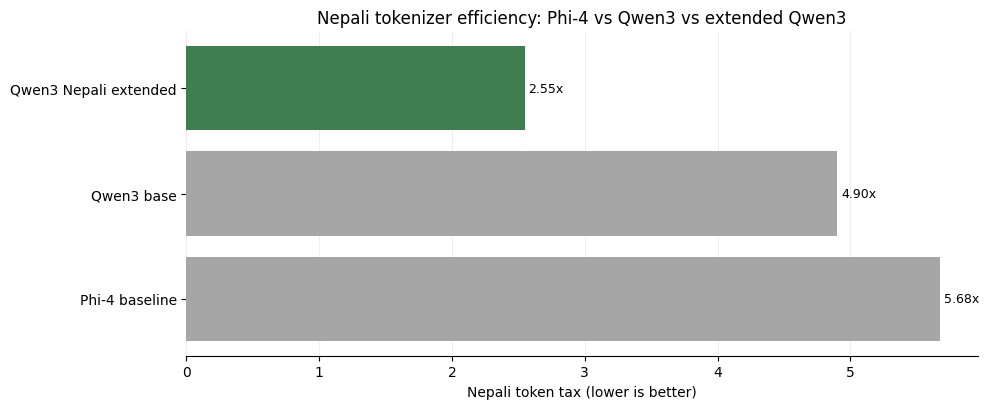

In [12]:
if plt is None:
    print('matplotlib is not installed; skipping chart. Install matplotlib to render it.')
else:
    plot_df = df.dropna(subset=['nepali_tax']).sort_values('nepali_tax', ascending=False).copy()
    colors = ['#3f7f4f' if 'Nepali extended' in name else '#a6a6a6' for name in plot_df['tokenizer']]

    fig, ax = plt.subplots(figsize=(10, 4.2))
    fig.patch.set_facecolor('white')
    ax.barh(plot_df['tokenizer'], plot_df['nepali_tax'], color=colors)
    ax.set_xlabel('Nepali token tax (lower is better)')
    ax.set_title('Nepali tokenizer efficiency: Phi-4 vs Qwen3 vs extended Qwen3')
    for i, value in enumerate(plot_df['nepali_tax']):
        ax.text(value + 0.03, i, f'{value:.2f}x', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


## Single-Sentence Comparison

This is a quick sanity check for one Nepali sentence. It is easier to inspect than corpus-level totals.

In [13]:
sample = 'नेपालको राजधानी काठमाडौं हो'
sample_rows = []
for item in loaded:
    try:
        ids = item['encode_fn'](sample)
        sample_rows.append({'tokenizer': item['name'], 'tokens': len(ids), 'ids_head': ids[:12]})
    except Exception as exc:
        sample_rows.append({'tokenizer': item['name'], 'tokens': None, 'ids_head': repr(exc)})

sample_df = pd.DataFrame(sample_rows).sort_values('tokens', na_position='last')
display(sample_df.style
    .format({'tokens': '{:.0f}'})
    .hide(axis='index')
    .set_properties(subset=['ids_head'], **{'font-family': 'monospace', 'font-size': '12px'})
)


tokenizer,tokens,ids_head
Qwen3 Nepali extended,7,"[157515, 220, 157590, 220, 153639, 84310, 54575]"
Qwen3 base,26,"[60096, 54784, 103, 31411, 110, 64704, 54575, 14925, 108, 31411, 250, 146821]"
Phi-4 baseline,30,"[61196, 35470, 87262, 24810, 92911, 65804, 55675, 15272, 108, 24810, 5619, 250]"


## Save Results

The result CSV is useful for checking whether future tokenizer updates change the ranking.

In [ ]:
out_dir = ROOT / 'results' / 'notebook'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'tokenizer_benchmark_from_notebook.csv'
df.to_csv(out_path, index=False)
print(f'Saved {out_path}')
